In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/simple-linear-regression-hours-vs-marks-data/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv


https://www.kaggle.com/datasets/souradippal/simple-linear-regression-hours-vs-marks-data

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("/kaggle/input/simple-linear-regression-hours-vs-marks-data/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")
df = pd.DataFrame(data)
df.head()

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


In [4]:
df.shape

(100, 2)

In [5]:
df.columns

Index(['Hours_Studied', 'Marks'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hours_Studied  100 non-null    float64
 1   Marks          100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [7]:
df.describe()

,Hours_Studied,Marks
count,100.000000,100.000000
mean,5.376300,46.360200
std,2.593013,14.284805
min,1.050000,20.190000
25%,3.175000,33.675000
50%,5.565000,47.485000
75%,7.255000,57.377500
max,9.870000,73.260000


In [8]:
df.isnull().sum()

Hours_Studied    0
Marks            0
dtype: int64

<Axes: xlabel='Hours_Studied', ylabel='Count'>

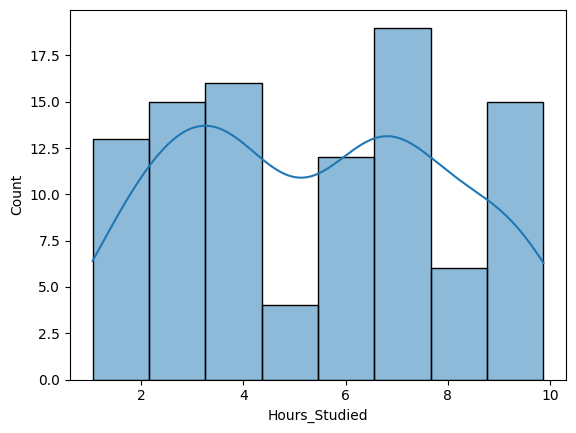

In [9]:
sns.histplot(data=df, x='Hours_Studied',kde=True)

<Axes: xlabel='Marks', ylabel='Count'>

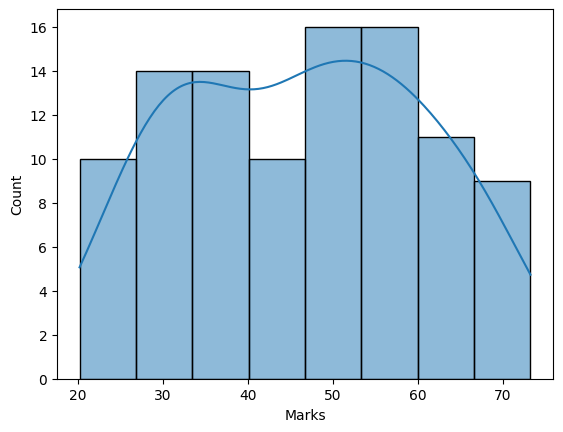

In [10]:
sns.histplot(data=df, x='Marks',kde=True)

In [11]:
df.corr()

,Hours_Studied,Marks
Hours_Studied,1.000000,0.948974
Marks,0.948974,1.000000


# ML

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [13]:
X = df[['Hours_Studied']]
y = df[['Marks']]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [15]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [16]:
model_prediction = model.predict(X_test)

r2 = r2_score(y_test, model_prediction)

print("MSE is:", mean_squared_error(y_test, model_prediction))
print("R2 Score:", r2)


MSE is: 13.285439094735377
R2 Score: 0.9336349643101417


In [17]:
n = X_test.shape[0]   # number of samples
p = X_test.shape[1]   # number of features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R2:", adjusted_r2)

Adjusted R2: 0.931494156707243
